In [1]:
import sys
from pathlib import Path

src_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), None)
if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory in current path or parent directories.")

sys.path.insert(0, str(src_path))
print(f"Added to sys.path: {src_path}")

Added to sys.path: /users/eleves-b/2023/keyvan.attarian/RL_project


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import time

from src.dvn.agent import DVNAgent1P, RoundPlanner3P
from src.blockblast.block_blast_3p_env import BlockBlast3PEnv
from src.dvn.models import BlockBlastValueNet1PmultikernelFlattenned


In [3]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [8]:
gamma = 0.99
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = BlockBlast3PEnv(lookahead_gamma=gamma)
agent = DVNAgent1P(policy_net=BlockBlastValueNet1PmultikernelFlattenned, device=device)
planner = RoundPlanner3P(env, agent)
agent.load_model("../final_weights/dvn_final_20260313_020137.pt")

print("Device:", device)

Device: cuda


In [ ]:
num_episodes = 200
max_steps_per_episode = 200

returns = []
lengths = []

for _ in tqdm(range(num_episodes), desc="3P DVN evaluation"):
    obs, _ = env.reset()
    planner.reset_round_plan()
    episode_return = 0.0

    for step in range(max_steps_per_episode):
        action = planner.select_action(env)
        if action is None:
            break

        obs, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward

        if terminated or truncated:
            break

    returns.append(episode_return)
    lengths.append(step + 1)

returns = np.array(returns, dtype=np.float32)
lengths = np.array(lengths, dtype=np.int32)

print(f"Average Return: {returns.mean():.2f} +- {returns.std():.2f}")
print(f"Average Episode Length: {lengths.mean():.2f} +- {lengths.std():.2f}")

3P DVN evaluation:   0%|          | 0/200 [00:02<?, ?it/s]


KeyboardInterrupt: 

NameError: name 'returns' is not defined

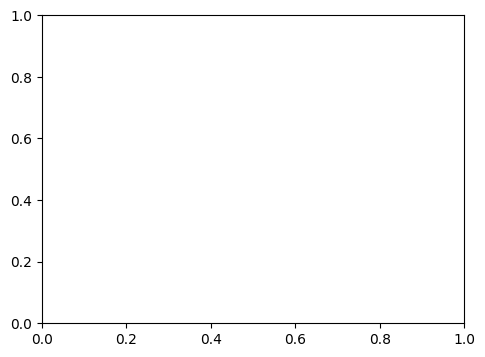

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(returns, bins=20, alpha=0.8)
plt.title("3P Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(lengths, bins=20, alpha=0.8)
plt.title("3P Episode Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

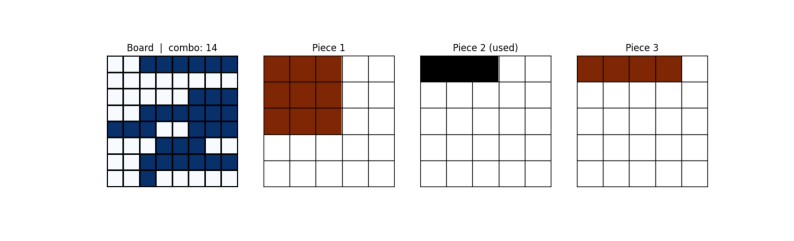

Step 29 | Reward: 0.10 | Total: 931.80
Episode finished.


In [ ]:
env_vis = BlockBlast3PEnv(render_mode="rgb_array", lookahead_gamma=gamma)
obs, _ = env_vis.reset()
planner = RoundPlanner3P(0.99, agent)
planner.reset_round_plan()
total_reward = 0.0
steps = 300

for t in range(steps):
    img = env_vis.render()
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    action = planner.select_action(env_vis)
    if action is None:
        print("No valid action available.")
        break
    clear_output(wait=True)
    obs, reward, terminated, truncated, _ = env_vis.step(action)
    total_reward += reward
    print(f"Step {t+1} | Reward: {reward:.2f} | Total: {total_reward:.2f}")

    time.sleep(0.2)
    if terminated or truncated:
        print("Episode finished.")
        break

env_vis.close()